   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 17.5 MB/s eta 0:00:00


Saving oasis_longitudinal.csv to oasis_longitudinal.csv
Shape: (373, 15)
  Subject ID         MRI ID        Group  Visit  MR Delay M/F Hand  Age  EDUC  \
0  OAS2_0001  OAS2_0001_MR1  Nondemented      1         0   M    R   87    14   
1  OAS2_0001  OAS2_0001_MR2  Nondemented      2       457   M    R   88    14   
2  OAS2_0002  OAS2_0002_MR1     Demented      1         0   M    R   75    12   
3  OAS2_0002  OAS2_0002_MR2     Demented      2       560   M    R   76    12   
4  OAS2_0002  OAS2_0002_MR3     Demented      3      1895   M    R   80    12   

   SES  MMSE  CDR  eTIV   nWBV    ASF  
0  2.0  27.0  0.0  1987  0.696  0.883  
1  2.0  30.0  0.0  2004  0.681  0.876  
2  NaN  23.0  0.5  1678  0.736  1.046  
3  NaN  28.0  0.5  1738  0.713  1.010  
4  NaN  22.0  0.5  1698  0.701  1.034  

Missing Values:
 Subject ID     0
MRI ID         0
Group          0
Visit          0
MR Delay       0
M/F            0
Hand           0
Age            0
EDUC           0
SES           19
MMSE        

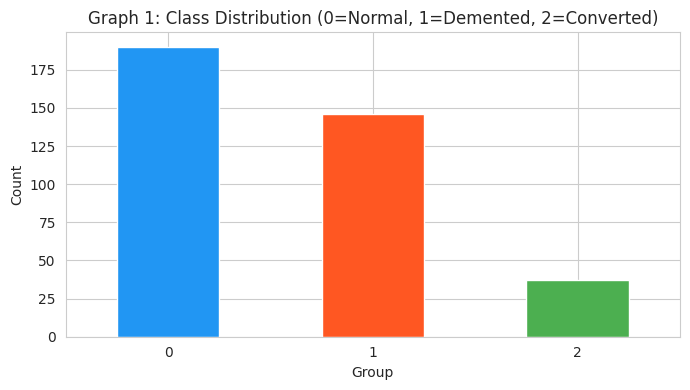

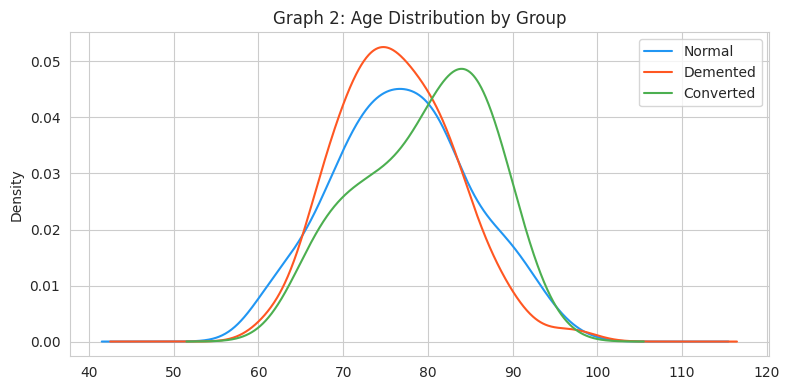

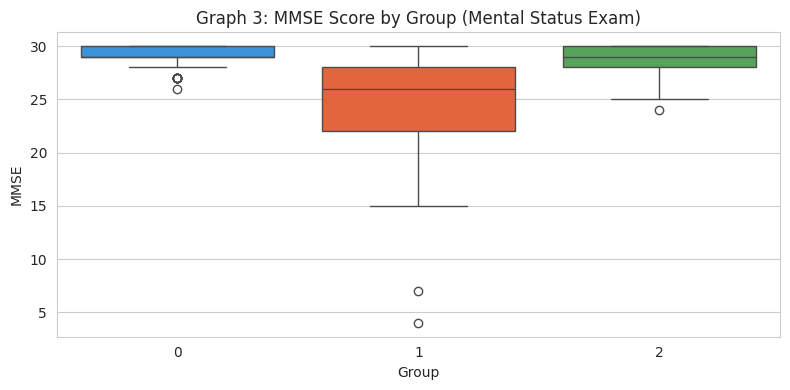

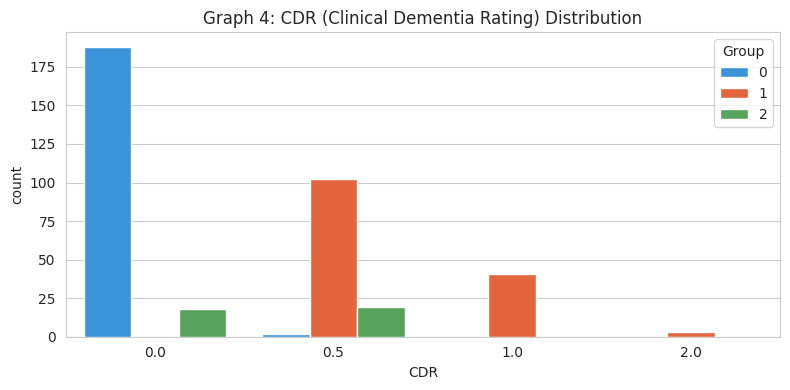

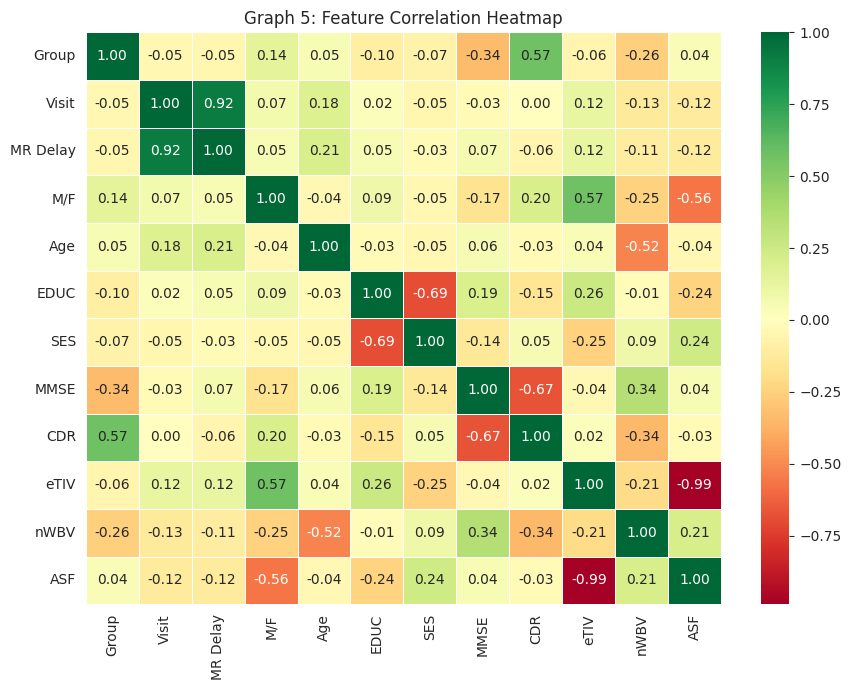

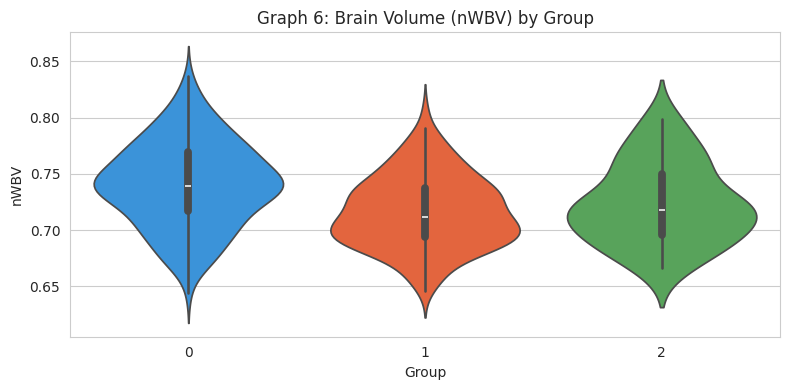

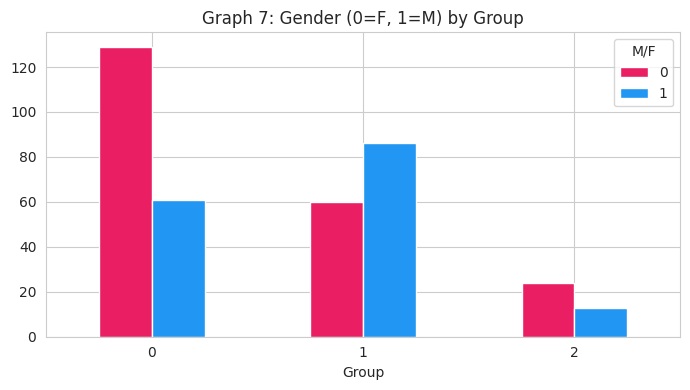

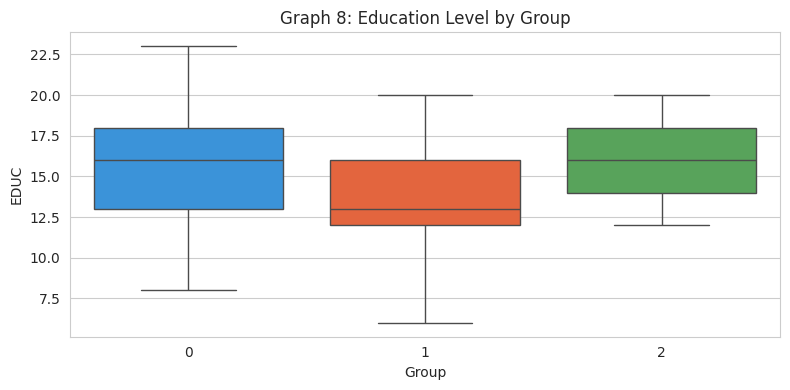

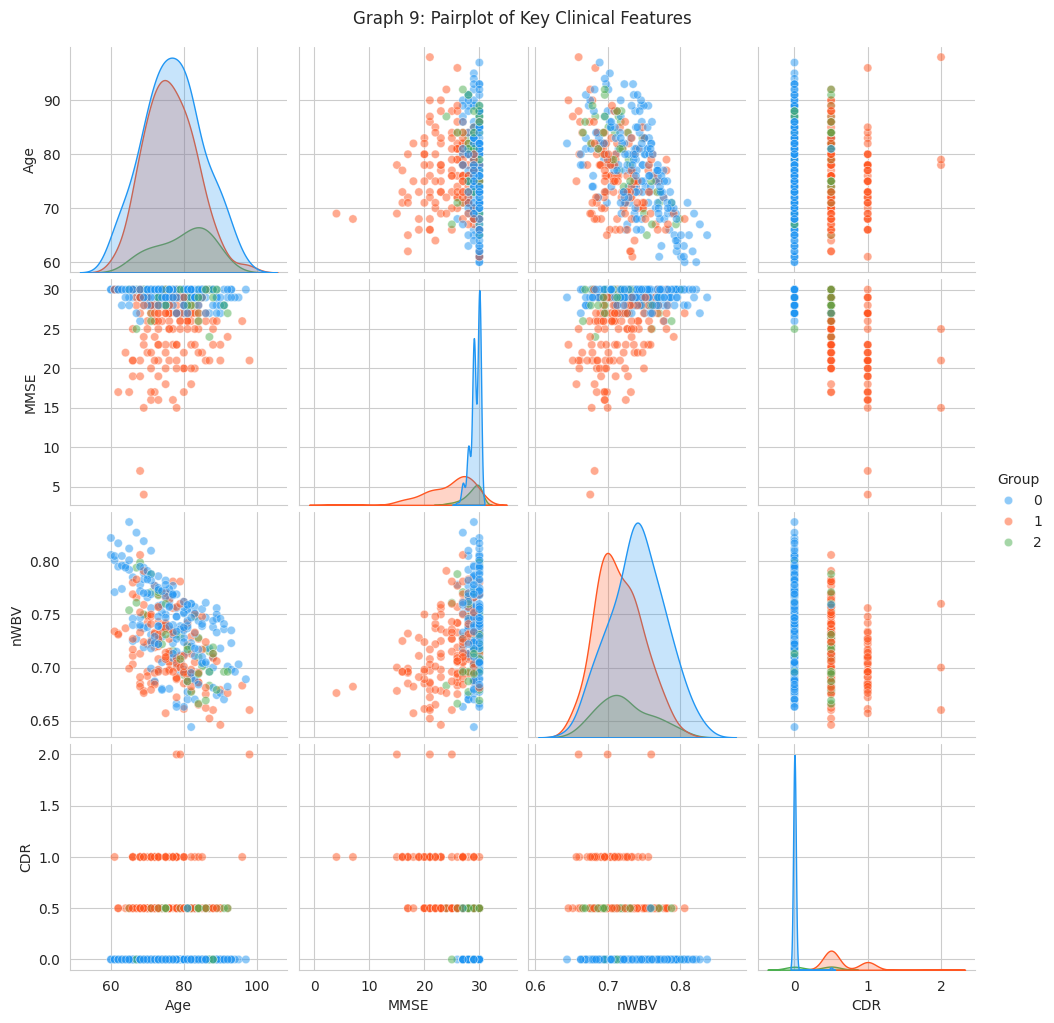

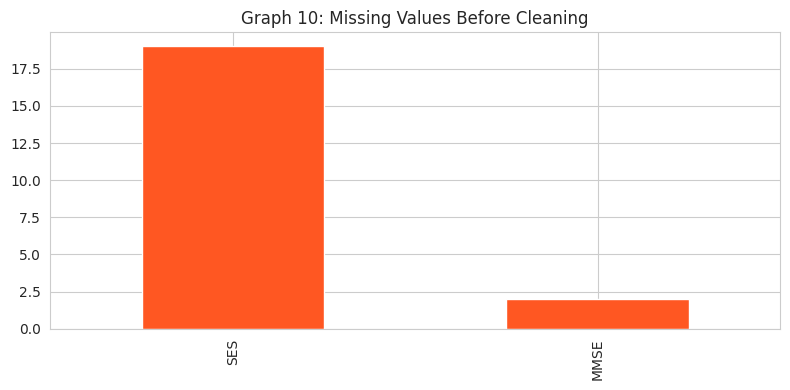


✅ 10 EDA graphs saved.


In [1]:
# ============================================================
# 1: Data Loading, Cleaning & Exploratory Analysis
# Dataset: OASIS Longitudinal (Kaggle)
# Upload 'oasis_longitudinal.csv' before running
# ============================================================

# --- Install & Imports ---
!pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost shap optuna imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# --- 1. Load Dataset ---
from google.colab import files
uploaded = files.upload()  # Upload oasis_longitudinal.csv

df = pd.read_csv('oasis_longitudinal.csv')
print("Shape:", df.shape)
print(df.head())
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)

# --- 2. Clean Dataset ---
# Drop irrelevant columns
df.drop(columns=['Subject ID', 'MRI ID', 'Hand', 'Delay'], inplace=True, errors='ignore')

# Fill missing values with median (numerical only)
for col in df.select_dtypes(include=[np.number]).columns:
    df[col].fillna(df[col].median(), inplace=True)

# Encode Gender: M=1, F=0
df['M/F'] = df['M/F'].map({'M': 1, 'F': 0})

# Encode target: Nondemented=0, Demented=1, Converted=2
df['Group'] = df['Group'].map({'Nondemented': 0, 'Demented': 1, 'Converted': 2})

# Drop remaining NaNs
df.dropna(inplace=True)

# Drop duplicate visits (keep first per subject)
df = df.sort_values('Visit').drop_duplicates(subset=['Subject ID'] if 'Subject ID' in df.columns else df.columns, keep='first')

print("\nCleaned Shape:", df.shape)
print("\nClass Distribution:\n", df['Group'].value_counts())

# ============================================================
# GRAPHS 1–10: Exploratory Data Analysis
# ============================================================

sns.set_style("whitegrid")
palette = ['#2196F3', '#FF5722', '#4CAF50']

# Graph 1: Class Distribution
fig, ax = plt.subplots(figsize=(7,4))
df['Group'].value_counts().plot(kind='bar', color=palette, ax=ax)
ax.set_title('Graph 1: Class Distribution (0=Normal, 1=Demented, 2=Converted)', fontsize=12)
ax.set_xlabel('Group'); ax.set_ylabel('Count')
plt.xticks(rotation=0); plt.tight_layout(); plt.savefig('graph_01_class_dist.png', dpi=150); plt.show()

# Graph 2: Age Distribution by Group
fig, ax = plt.subplots(figsize=(8,4))
for g, color in zip([0,1,2], palette):
    df[df['Group']==g]['Age'].plot(kind='kde', ax=ax, color=color, label=['Normal','Demented','Converted'][g])
ax.set_title('Graph 2: Age Distribution by Group'); ax.legend(); plt.tight_layout()
plt.savefig('graph_02_age_dist.png', dpi=150); plt.show()

# Graph 3: MMSE Score Distribution
fig, ax = plt.subplots(figsize=(8,4))
sns.boxplot(x='Group', y='MMSE', data=df, palette=palette, ax=ax)
ax.set_title('Graph 3: MMSE Score by Group (Mental Status Exam)')
plt.tight_layout(); plt.savefig('graph_03_mmse_box.png', dpi=150); plt.show()

# Graph 4: CDR Distribution
fig, ax = plt.subplots(figsize=(8,4))
sns.countplot(x='CDR', hue='Group', data=df, palette=palette, ax=ax)
ax.set_title('Graph 4: CDR (Clinical Dementia Rating) Distribution')
plt.tight_layout(); plt.savefig('graph_04_cdr_count.png', dpi=150); plt.show()

# Graph 5: Correlation Heatmap
fig, ax = plt.subplots(figsize=(9,7))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax, linewidths=0.5)
ax.set_title('Graph 5: Feature Correlation Heatmap')
plt.tight_layout(); plt.savefig('graph_05_correlation.png', dpi=150); plt.show()

# Graph 6: nWBV (Normalized Whole Brain Volume) by Group
fig, ax = plt.subplots(figsize=(8,4))
sns.violinplot(x='Group', y='nWBV', data=df, palette=palette, ax=ax)
ax.set_title('Graph 6: Brain Volume (nWBV) by Group')
plt.tight_layout(); plt.savefig('graph_06_nwbv_violin.png', dpi=150); plt.show()

# Graph 7: Gender Distribution per Group
fig, ax = plt.subplots(figsize=(7,4))
pd.crosstab(df['Group'], df['M/F']).plot(kind='bar', color=['#E91E63','#2196F3'], ax=ax)
ax.set_title('Graph 7: Gender (0=F, 1=M) by Group')
plt.xticks(rotation=0); plt.tight_layout(); plt.savefig('graph_07_gender.png', dpi=150); plt.show()

# Graph 8: Education Level vs Group
fig, ax = plt.subplots(figsize=(8,4))
sns.boxplot(x='Group', y='EDUC', data=df, palette=palette, ax=ax)
ax.set_title('Graph 8: Education Level by Group')
plt.tight_layout(); plt.savefig('graph_08_education.png', dpi=150); plt.show()

# Graph 9: Pairplot of key features
key_cols = ['Age', 'MMSE', 'nWBV', 'CDR', 'Group']
pair_df = df[key_cols].copy()
g = sns.pairplot(pair_df, hue='Group', palette={0:'#2196F3',1:'#FF5722',2:'#4CAF50'}, diag_kind='kde', plot_kws={'alpha':0.5})
g.fig.suptitle('Graph 9: Pairplot of Key Clinical Features', y=1.02)
plt.savefig('graph_09_pairplot.png', dpi=100, bbox_inches='tight'); plt.show()

# Graph 10: Feature Missing Value Summary (before cleaning)
fig, ax = plt.subplots(figsize=(8,4))
missing = pd.read_csv('oasis_longitudinal.csv').isnull().sum()
missing[missing > 0].plot(kind='bar', color='#FF5722', ax=ax)
ax.set_title('Graph 10: Missing Values Before Cleaning')
plt.tight_layout(); plt.savefig('graph_10_missing.png', dpi=150); plt.show()

print("\n✅ 10 EDA graphs saved.")

✅ Selected Features: ['EDUC', 'nWBV', 'CDR', 'ASF', 'M/F', 'MMSE', 'MR Delay', 'eTIV']


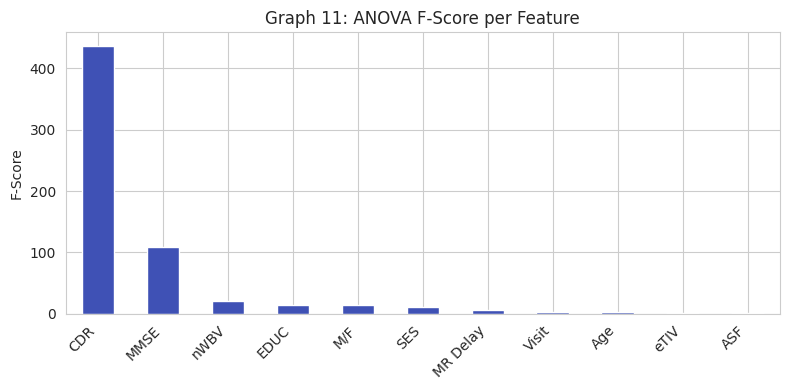

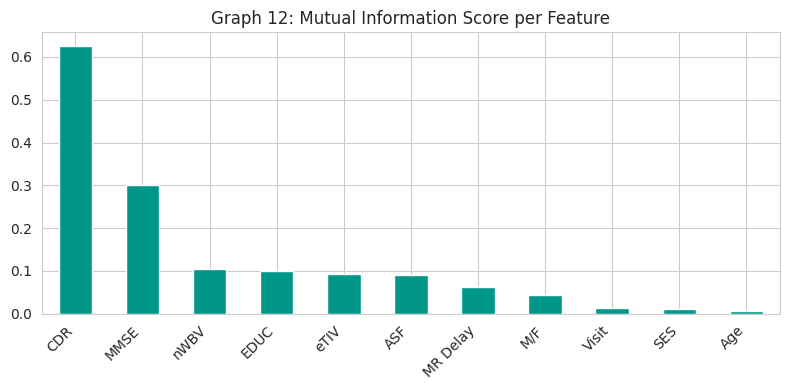

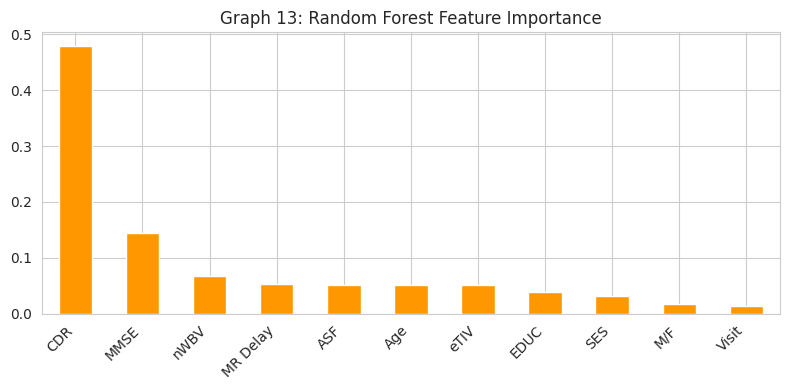

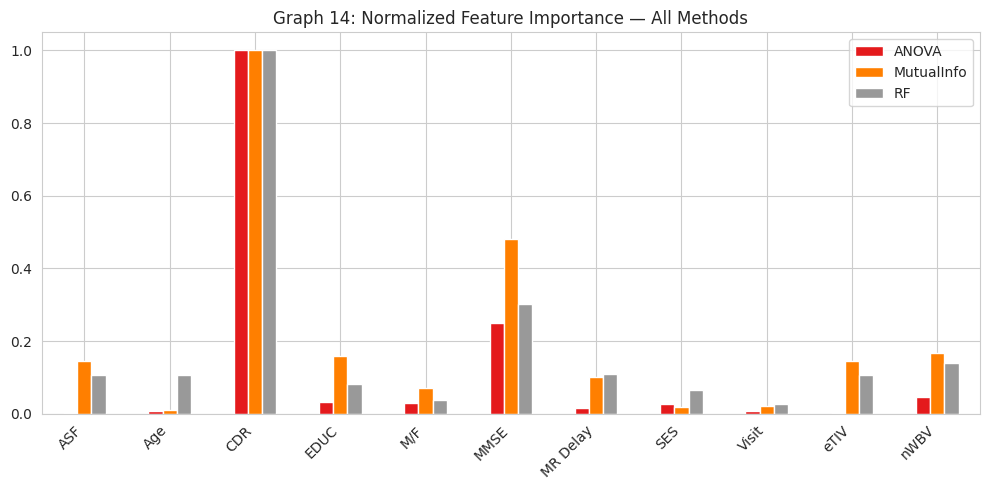

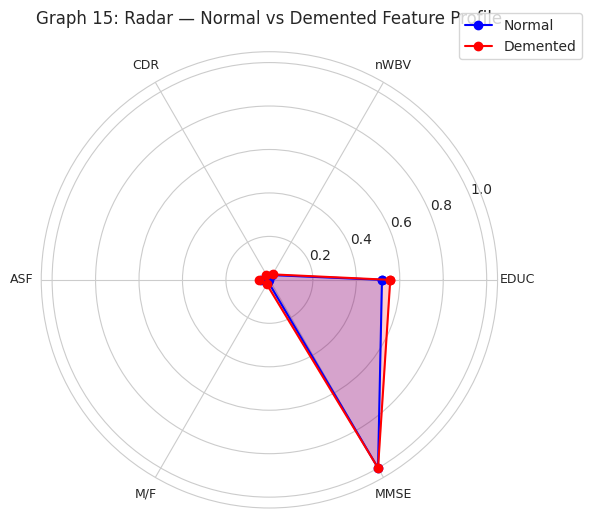


✅ Features selected: ['EDUC', 'nWBV', 'CDR', 'ASF', 'M/F', 'MMSE', 'MR Delay', 'eTIV']


In [2]:
# ============================================================
# 2: Automatic Feature Selection
#  (uses cleaned 'df')
# ============================================================

from sklearn.feature_selection import (SelectKBest, f_classif,
                                        mutual_info_classif, RFE)
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

X = df.drop(columns=['Group'])
y = df['Group']

feature_names = X.columns.tolist()

# --- Method 1: ANOVA F-Score ---
selector_f = SelectKBest(f_classif, k='all')
selector_f.fit(X, y)
f_scores = pd.Series(selector_f.scores_, index=feature_names).sort_values(ascending=False)

# --- Method 2: Mutual Information ---
mi_scores = pd.Series(
    mutual_info_classif(X, y, random_state=42),
    index=feature_names).sort_values(ascending=False)

# --- Method 3: Random Forest Importance ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
rf_importance = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

# --- Select Top Features (union of top-5 from each method) ---
top_features = list(set(
    f_scores.head(5).index.tolist() +
    mi_scores.head(5).index.tolist() +
    rf_importance.head(5).index.tolist()
))
print("✅ Selected Features:", top_features)

X_selected = X[top_features]

# ============================================================
# GRAPHS 11–15: Feature Selection Visualizations
# ============================================================

# Graph 11: ANOVA F-Scores
fig, ax = plt.subplots(figsize=(8,4))
f_scores.plot(kind='bar', color='#3F51B5', ax=ax)
ax.set_title('Graph 11: ANOVA F-Score per Feature')
ax.set_ylabel('F-Score'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.savefig('graph_11_anova.png', dpi=150); plt.show()

# Graph 12: Mutual Information Scores
fig, ax = plt.subplots(figsize=(8,4))
mi_scores.plot(kind='bar', color='#009688', ax=ax)
ax.set_title('Graph 12: Mutual Information Score per Feature')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig('graph_12_mutual_info.png', dpi=150); plt.show()

# Graph 13: Random Forest Importance
fig, ax = plt.subplots(figsize=(8,4))
rf_importance.plot(kind='bar', color='#FF9800', ax=ax)
ax.set_title('Graph 13: Random Forest Feature Importance')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig('graph_13_rf_importance.png', dpi=150); plt.show()

# Graph 14: Feature Importance Comparison (combined)
compare_df = pd.DataFrame({
    'ANOVA': f_scores / f_scores.max(),
    'MutualInfo': mi_scores / mi_scores.max(),
    'RF': rf_importance / rf_importance.max()
})
fig, ax = plt.subplots(figsize=(10,5))
compare_df.plot(kind='bar', ax=ax, colormap='Set1')
ax.set_title('Graph 14: Normalized Feature Importance — All Methods')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig('graph_14_feature_comparison.png', dpi=150); plt.show()

# Graph 15: Selected Features Radar (CDR, MMSE, nWBV, Age, EDUC)
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

categories = top_features[:6] if len(top_features) >= 6 else top_features
N = len(categories)
values_0 = df[df['Group']==0][categories].mean().values.tolist()
values_1 = df[df['Group']==1][categories].mean().values.tolist()

# Normalize
for lst in [values_0, values_1]:
    mx = max(lst) if max(lst) != 0 else 1
    lst[:] = [v/mx for v in lst]

angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]
values_0 += values_0[:1]; values_1 += values_1[:1]

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
ax.plot(angles, values_0, 'b-o', label='Normal'); ax.fill(angles, values_0, alpha=0.2, color='blue')
ax.plot(angles, values_1, 'r-o', label='Demented'); ax.fill(angles, values_1, alpha=0.2, color='red')
ax.set_xticks(angles[:-1]); ax.set_xticklabels(categories, fontsize=9)
ax.set_title('Graph 15: Radar — Normal vs Demented Feature Profile', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.tight_layout(); plt.savefig('graph_15_radar.png', dpi=150); plt.show()

print("\n✅ Features selected:", top_features)

✅ After SMOTE: {0: 190, 1: 190, 2: 190}


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Best Params:   {'n_estimators': 252, 'max_depth': 4, 'learning_rate': 0.08947088910834887, 'subsample': 0.7670078662720239, 'colsample_bytree': 0.9149091549888475, 'gamma': 0.025786010887926945, 'reg_alpha': 1.5432669989641696, 'reg_lambda': 0.8651661350664784, 'min_child_weight': 4, 'use_label_encoder': False, 'eval_metric': 'mlogloss', 'random_state': 42, 'objective': 'multi:softmax', 'num_class': 3, 'verbosity': 0}
✅ Best F1-Macro: 0.9237


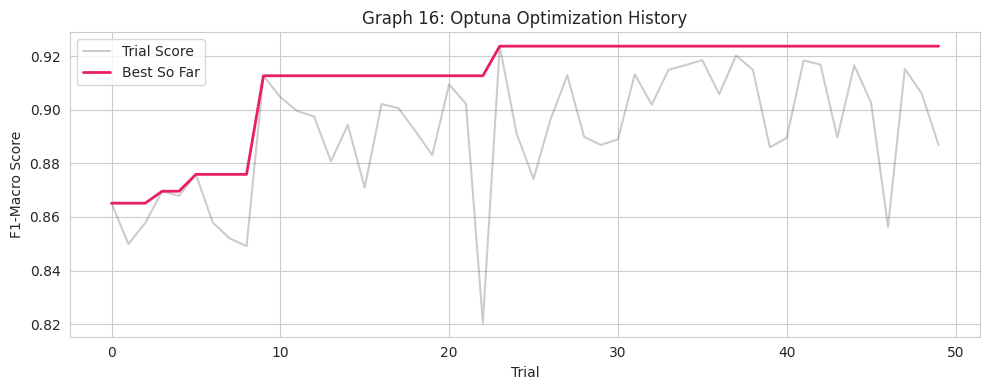

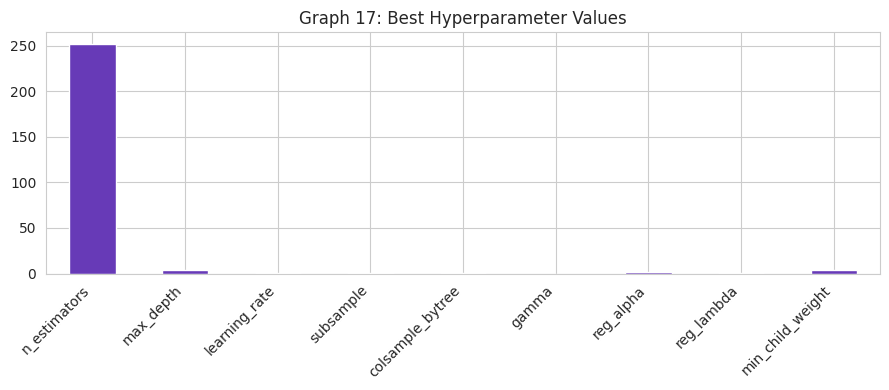

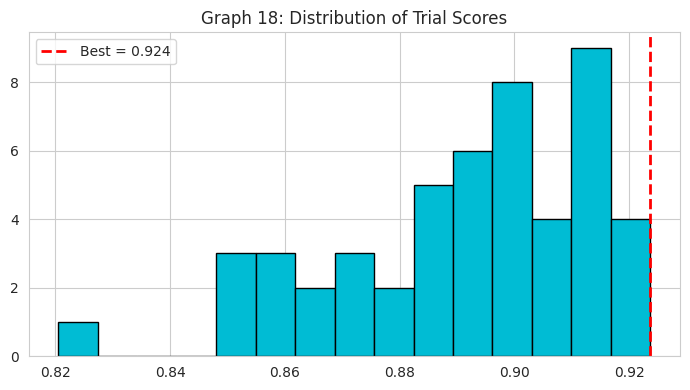

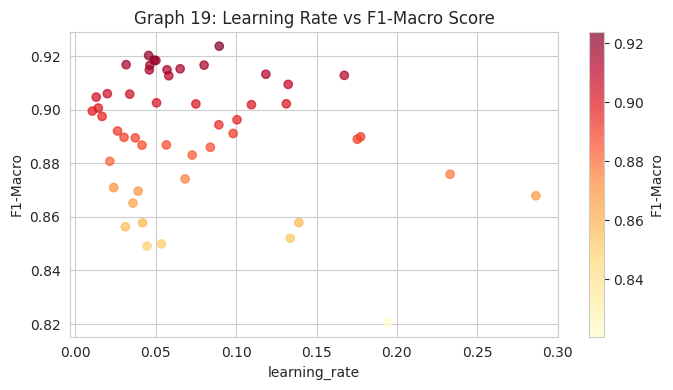

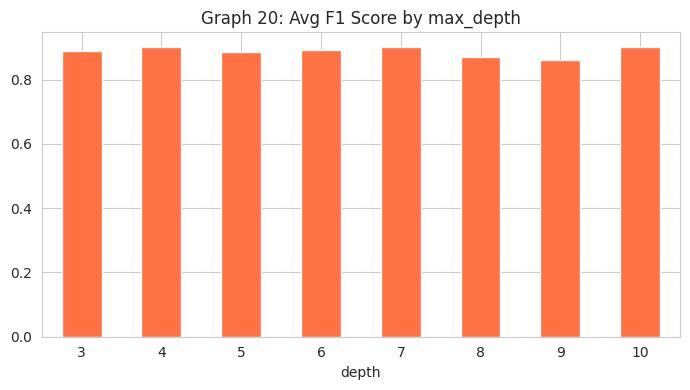


✅ Hyperparameter Tuning with Optuna Completed — Graphs 16–20 done.


In [8]:
# ============================================================
# CELL 3: Hyperparameter Tuning with Optuna + Graphs 16-20
# Run AFTER Cell 2
# ============================================================

import optuna
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

# --- SMOTE: Balance Classes ---
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_selected, y)
print("✅ After SMOTE:", pd.Series(y_res).value_counts().to_dict())

# Encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y_res)

# --- Optuna Objective ---
def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma':             trial.suggest_float('gamma', 0, 5),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.5, 5),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'use_label_encoder': False,
        'eval_metric':       'mlogloss',
        'random_state':      42,
        'objective':         'multi:softmax',
        'num_class':         3,
        'verbosity':         0
    }
    model = xgb.XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_res, y_enc,
                             cv=cv, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

# --- Run Study ---
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize',
                            study_name='XGBoost_MCI_Alzheimer')
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params.copy()
best_params.update({
    'use_label_encoder': False,
    'eval_metric':       'mlogloss',
    'random_state':      42,
    'objective':         'multi:softmax',
    'num_class':         3,
    'verbosity':         0
})
print(f"\n✅ Best Params:   {best_params}")
print(f"✅ Best F1-Macro: {study.best_value:.4f}")

# ============================================================
# GRAPHS 16–20: Tuning Visualizations
# ============================================================

trials     = [t.number for t in study.trials]
values     = [t.value  for t in study.trials]
best_curve = pd.Series(values).cummax().values

# Graph 16: Optimization History
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(trials, values,     alpha=0.4, color='gray',   label='Trial Score')
ax.plot(trials, best_curve, color='#E91E63', lw=2,     label='Best So Far')
ax.set_title('Graph 16: Optuna Optimization History')
ax.set_xlabel('Trial'); ax.set_ylabel('F1-Macro Score')
ax.legend(); plt.tight_layout()
plt.savefig('graph_16_optuna_history.png', dpi=150); plt.show()

# Graph 17: Best Hyperparameter Values
skip_keys = {'use_label_encoder', 'random_state', 'num_class',
             'eval_metric', 'objective', 'verbosity'}
param_vals = pd.Series({
    k: v for k, v in best_params.items()
    if isinstance(v, (int, float)) and k not in skip_keys
})
fig, ax = plt.subplots(figsize=(9, 4))
param_vals.plot(kind='bar', color='#673AB7', ax=ax)
ax.set_title('Graph 17: Best Hyperparameter Values')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig('graph_17_best_params.png', dpi=150); plt.show()

# Graph 18: Trial Score Distribution
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(values, bins=15, color='#00BCD4', edgecolor='black')
ax.axvline(study.best_value, color='red', lw=2, linestyle='--',
           label=f'Best = {study.best_value:.3f}')
ax.set_title('Graph 18: Distribution of Trial Scores')
ax.legend(); plt.tight_layout()
plt.savefig('graph_18_trial_dist.png', dpi=150); plt.show()

# Graph 19: Learning Rate vs Score
lr_vals = [t.params['learning_rate'] for t in study.trials]
fig, ax = plt.subplots(figsize=(7, 4))
sc = ax.scatter(lr_vals, values, c=values, cmap='YlOrRd', alpha=0.7)
plt.colorbar(sc, ax=ax, label='F1-Macro')
ax.set_title('Graph 19: Learning Rate vs F1-Macro Score')
ax.set_xlabel('learning_rate'); ax.set_ylabel('F1-Macro')
plt.tight_layout()
plt.savefig('graph_19_lr_scatter.png', dpi=150); plt.show()

# Graph 20: Max Depth vs Avg Score
depth_vals = [t.params['max_depth'] for t in study.trials]
depth_df   = pd.DataFrame({'depth': depth_vals, 'score': values})
fig, ax = plt.subplots(figsize=(7, 4))
depth_df.groupby('depth')['score'].mean().plot(kind='bar',
                                               color='#FF7043', ax=ax)
ax.set_title('Graph 20: Avg F1 Score by max_depth')
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig('graph_20_depth_score.png', dpi=150); plt.show()

print("\n✅ Hyperparameter Tuning with Optuna Completed — Graphs 16–20 done.")

=== Classification Report ===
              precision    recall  f1-score   support

      Normal       0.88      0.95      0.91        38
    Demented       0.97      0.89      0.93        38
   Converted       0.87      0.87      0.87        38

    accuracy                           0.90       114
   macro avg       0.91      0.90      0.90       114
weighted avg       0.91      0.90      0.90       114



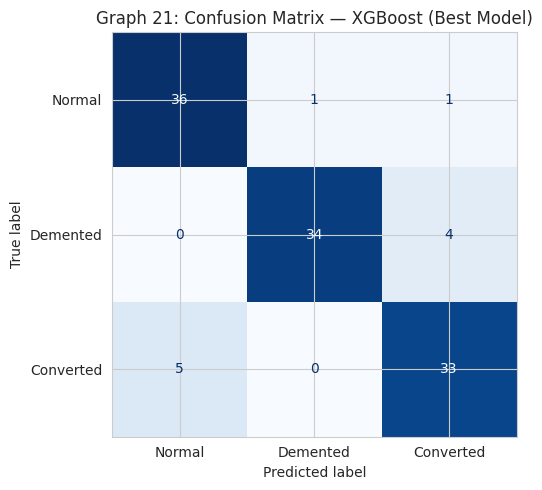

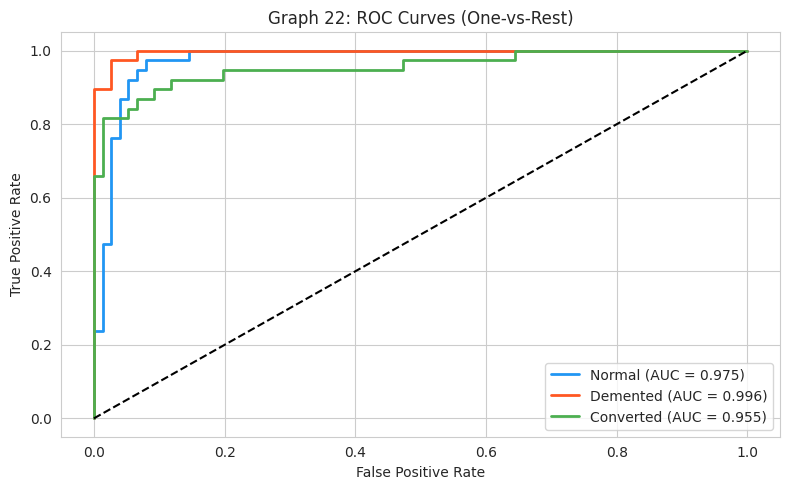

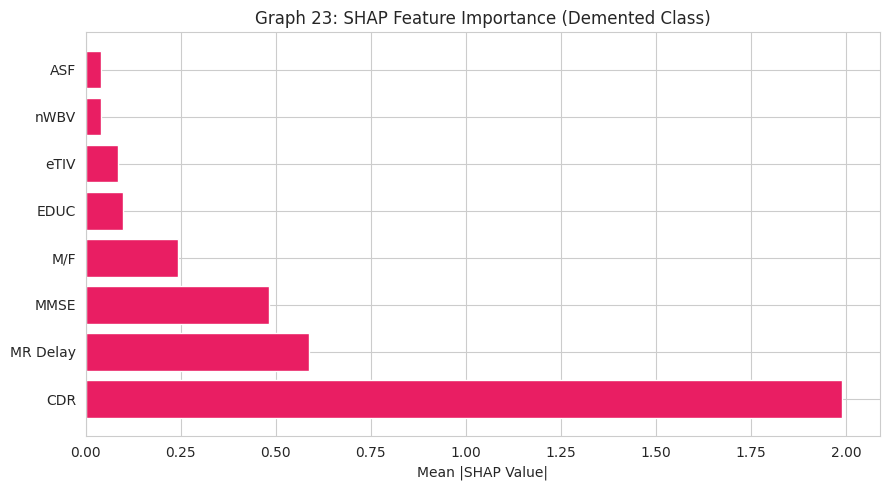

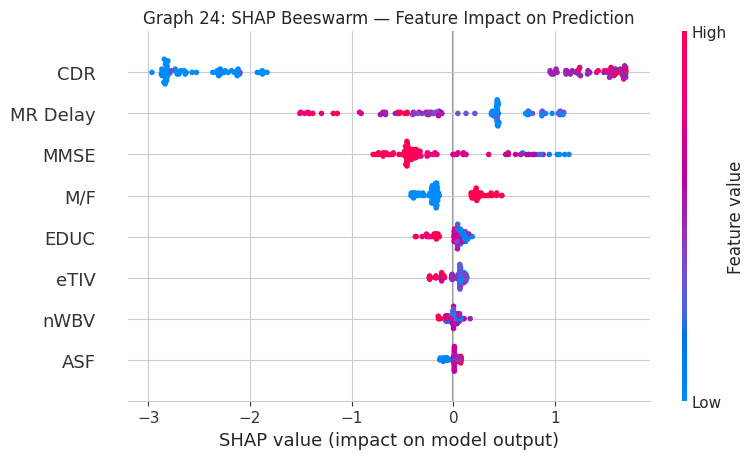

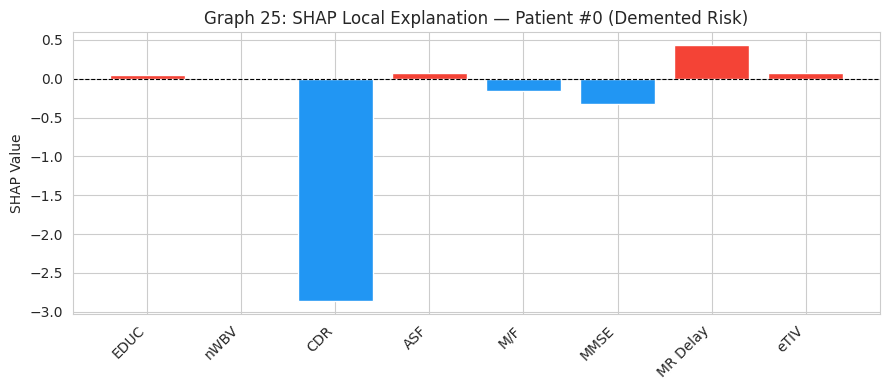


✅ Model Training + SHAP Explainability Completed — Graphs 21–25 done.


In [11]:
# ============================================================
# CELL 4: Model Training + SHAP Explainability (Graphs 21-25)
# ============================================================

import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              roc_curve)
from sklearn.preprocessing import label_binarize
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# --- Train / Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

# --- Train Best Model ---
best_model = xgb.XGBClassifier(**best_params)
best_model.fit(X_train, y_train,
               eval_set=[(X_test, y_test)],
               verbose=False)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred,
      target_names=['Normal', 'Demented', 'Converted']))

# --- Compute SHAP Values ---
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Safely extract Demented class (class 1) SHAP → shape (n_samples, n_features)
def get_shap_2d(sv, cls=1):
    if isinstance(sv, list):
        arr = np.array(sv[cls])
    else:
        arr = np.array(sv)
    if arr.ndim == 3:          # (n_samples, n_features, n_classes)
        arr = arr[:, :, cls]
    if arr.ndim == 1:          # edge case: single sample
        arr = arr.reshape(1, -1)
    return arr                 # always (n_samples, n_features)

shap_2d = get_shap_2d(shap_values, cls=1)

# Align SHAP columns to top_features
feature_cols = list(X_test.columns)
top_idx      = [feature_cols.index(f) for f in top_features
                if f in feature_cols]
shap_top     = shap_2d[:, top_idx]   # (n_samples, len(top_features))

# ============================================================
# GRAPHS 21–25
# ============================================================

# Graph 21: Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm,
       display_labels=['Normal', 'Demented', 'Converted'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Graph 21: Confusion Matrix — XGBoost (Best Model)')
plt.tight_layout()
plt.savefig('graph_21_confusion_matrix.png', dpi=150); plt.show()

# Graph 22: ROC Curves (One-vs-Rest)
y_bin       = label_binarize(y_test, classes=[0, 1, 2])
class_names = ['Normal', 'Demented', 'Converted']
colors_roc  = ['#2196F3', '#FF5722', '#4CAF50']

fig, ax = plt.subplots(figsize=(8, 5))
for i, (cname, color) in enumerate(zip(class_names, colors_roc)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    auc_val      = roc_auc_score(y_bin[:, i], y_prob[:, i])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{cname} (AUC = {auc_val:.3f})')
ax.plot([0, 1], [0, 1], 'k--')
ax.set_title('Graph 22: ROC Curves (One-vs-Rest)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(); plt.tight_layout()
plt.savefig('graph_22_roc_curves.png', dpi=150); plt.show()

# Graph 23: SHAP Global Importance Bar
mean_abs = np.abs(shap_top).mean(axis=0)
order    = np.argsort(mean_abs)[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh([top_features[i] for i in order],
        mean_abs[order], color='#E91E63')
ax.set_title('Graph 23: SHAP Feature Importance (Demented Class)')
ax.set_xlabel('Mean |SHAP Value|')
plt.tight_layout()
plt.savefig('graph_23_shap_importance.png', dpi=150); plt.show()

# Graph 24: SHAP Beeswarm
shap_exp = shap.Explanation(
    values        = shap_top,
    data          = np.array(X_test[top_features]),
    feature_names = top_features
)
plt.figure(figsize=(9, 5))
shap.plots.beeswarm(shap_exp, show=False)
plt.title('Graph 24: SHAP Beeswarm — Feature Impact on Prediction')
plt.tight_layout()
plt.savefig('graph_24_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# Graph 25: SHAP Local Explanation (single patient)
patient_idx = 0
sv_patient  = shap_top[patient_idx]   # guaranteed 1D, length = len(top_features)

colors_bar = ['#F44336' if float(v) > 0 else '#2196F3' for v in sv_patient]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(top_features, sv_patient, color=colors_bar)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title(f'Graph 25: SHAP Local Explanation — '
             f'Patient #{patient_idx} (Demented Risk)')
ax.set_ylabel('SHAP Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('graph_25_shap_local.png', dpi=150); plt.show()

print("\n✅ Model Training + SHAP Explainability Completed — Graphs 21–25 done.")

XGBoost (Tuned)      | Acc=0.904 | F1=0.904 | AUC=0.975
Random Forest        | Acc=0.904 | F1=0.904 | AUC=0.978
GradBoost            | Acc=0.904 | F1=0.903 | AUC=0.973
Logistic Reg         | Acc=0.719 | F1=0.711 | AUC=0.926
SVM                  | Acc=0.421 | F1=0.364 | AUC=0.541

                  Accuracy  F1-Macro   AUC-OvR
Model                                        
XGBoost (Tuned)  0.903509  0.903773  0.975185
Random Forest    0.903509  0.904131  0.978012
GradBoost        0.903509  0.902928  0.973453
Logistic Reg     0.719298  0.710505  0.926477
SVM              0.421053  0.363758  0.541205


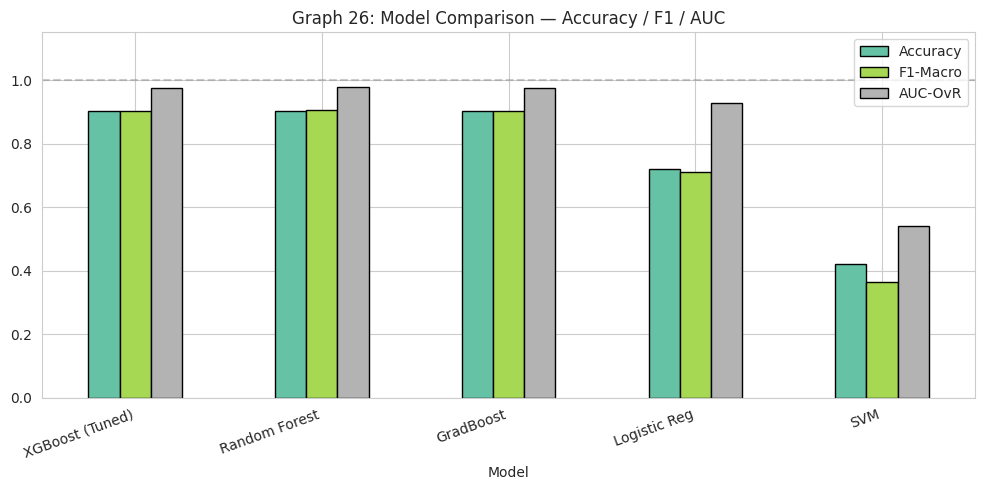

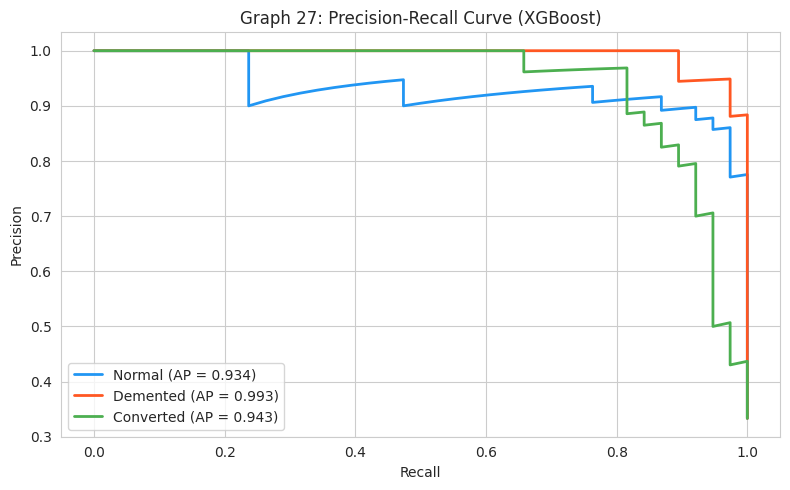

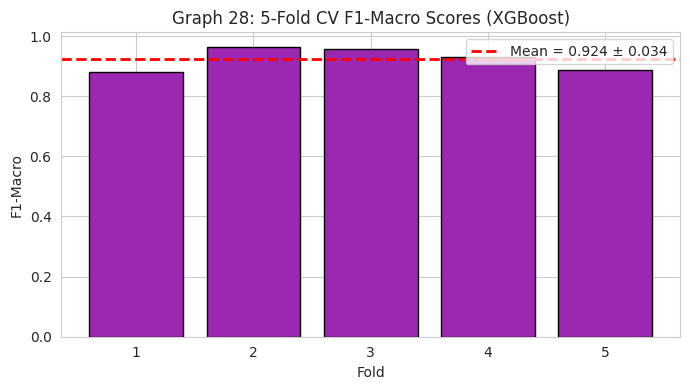

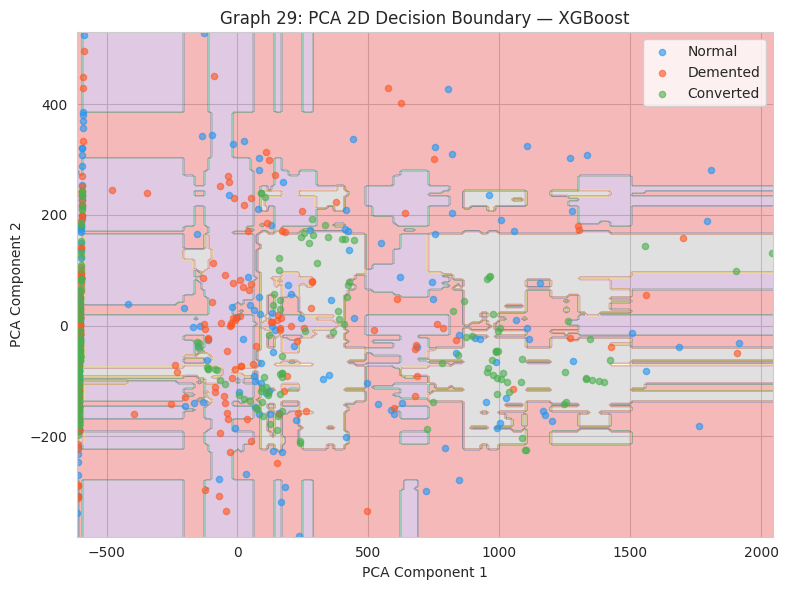

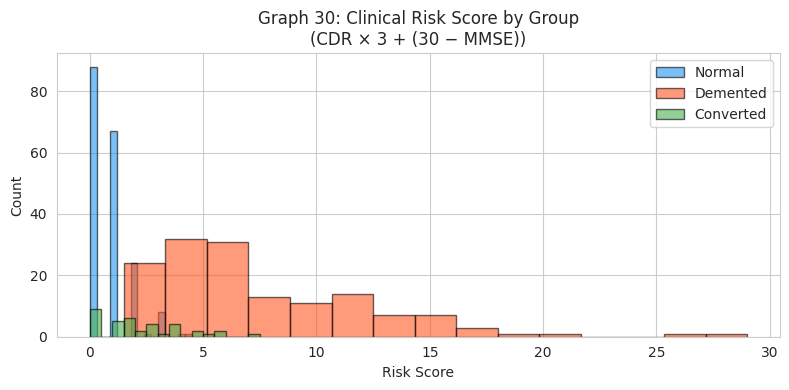


✅ ALL 30 GRAPHS COMPLETE
✅ XGBoost CV F1-Macro : 0.9237 ± 0.0344
✅ XGBoost AUC-OvR     : 0.9752


In [12]:
# ============================================================
# CELL 5: Model Comparison + Final Graphs (26-30)
# ============================================================

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (f1_score, accuracy_score, roc_auc_score,
                              precision_recall_curve, average_precision_score)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.decomposition import PCA
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
class_names = ['Normal', 'Demented', 'Converted']

# --- Compare 5 Models ---
models = {
    'XGBoost (Tuned)': best_model,
    'Random Forest':   RandomForestClassifier(n_estimators=100, random_state=42),
    'GradBoost':       GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Reg':    LogisticRegression(max_iter=1000, random_state=42),
    'SVM':             SVC(probability=True, random_state=42)
}

results = []
for name, model in models.items():
    if name != 'XGBoost (Tuned)':
        model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)
    y_bin = label_binarize(y_test, classes=[0, 1, 2])
    auc   = roc_auc_score(y_bin, probs, multi_class='ovr')
    results.append({
        'Model':    name,
        'Accuracy': accuracy_score(y_test, preds),
        'F1-Macro': f1_score(y_test, preds, average='macro'),
        'AUC-OvR':  auc
    })
    print(f"{name:20s} | Acc={accuracy_score(y_test,preds):.3f} "
          f"| F1={f1_score(y_test,preds,average='macro'):.3f} "
          f"| AUC={auc:.3f}")

results_df = pd.DataFrame(results).set_index('Model')
print("\n", results_df)

# Graph 26: Model Comparison
fig, ax = plt.subplots(figsize=(10, 5))
results_df.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black')
ax.set_title('Graph 26: Model Comparison — Accuracy / F1 / AUC')
ax.set_ylim(0, 1.15)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.4)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('graph_26_model_compare.png', dpi=150); plt.show()

# Graph 27: Precision-Recall Curve
y_bin      = label_binarize(y_test, classes=[0, 1, 2])
colors_pr  = ['#2196F3', '#FF5722', '#4CAF50']

fig, ax = plt.subplots(figsize=(8, 5))
for i, (cname, color) in enumerate(zip(class_names, colors_pr)):
    prec, rec, _ = precision_recall_curve(y_bin[:, i], y_prob[:, i])
    ap = average_precision_score(y_bin[:, i], y_prob[:, i])
    ax.plot(rec, prec, color=color, lw=2,
            label=f'{cname} (AP = {ap:.3f})')
ax.set_title('Graph 27: Precision-Recall Curve (XGBoost)')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.legend(); plt.tight_layout()
plt.savefig('graph_27_pr_curve.png', dpi=150); plt.show()

# Graph 28: 5-Fold Cross Validation
cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_res, y_enc,
                             cv=cv, scoring='f1_macro')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 6), cv_scores, color='#9C27B0', edgecolor='black')
ax.axhline(cv_scores.mean(), color='red', lw=2, linestyle='--',
           label=f'Mean = {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
ax.set_title('Graph 28: 5-Fold CV F1-Macro Scores (XGBoost)')
ax.set_xlabel('Fold'); ax.set_ylabel('F1-Macro')
ax.legend(); plt.tight_layout()
plt.savefig('graph_28_cv_scores.png', dpi=150); plt.show()

# Graph 29: PCA 2D Decision Boundary
pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_res)

x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

xgb_pca = xgb.XGBClassifier(**best_params)
xgb_pca.fit(X_2d, y_enc)
Z = xgb_pca.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')
scatter_colors = ['#2196F3', '#FF5722', '#4CAF50']
for cls, color, lbl in zip([0, 1, 2], scatter_colors, class_names):
    mask = y_enc == cls
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=color, label=lbl, s=20, alpha=0.6)
ax.set_title('Graph 29: PCA 2D Decision Boundary — XGBoost')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.legend(); plt.tight_layout()
plt.savefig('graph_29_decision_boundary.png', dpi=150); plt.show()

# Graph 30: Clinical Risk Score
df['Risk_Score'] = (df['CDR'] * 3) + (30 - df['MMSE'])

fig, ax = plt.subplots(figsize=(8, 4))
for g, color, label in zip([0, 1, 2],
                            ['#2196F3', '#FF5722', '#4CAF50'],
                            class_names):
    data = df[df['Group'] == g]['Risk_Score']
    ax.hist(data, bins=15, alpha=0.6, color=color,
            label=label, edgecolor='black')
ax.set_title('Graph 30: Clinical Risk Score by Group\n'
             '(CDR × 3 + (30 − MMSE))')
ax.set_xlabel('Risk Score'); ax.set_ylabel('Count')
ax.legend(); plt.tight_layout()
plt.savefig('graph_30_risk_score.png', dpi=150); plt.show()

print("\n" + "=" * 60)
print("✅ ALL 30 GRAPHS COMPLETE")
print(f"✅ XGBoost CV F1-Macro : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"✅ XGBoost AUC-OvR     : {results_df.loc['XGBoost (Tuned)', 'AUC-OvR']:.4f}")
print("=" * 60)

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
